<div style="color:#3c4d5a; border-top: 7px solid #42A5F5; border-bottom: 7px solid #42A5F5; padding: 15px; text-align: center; text-transform: uppercase">
    <h1>Informe de Análisis Exploratorio de Datos</h1>
    <h3>Detección de Fraude en Tarjetas de Crédito</h3>
</div>

**Desarrollado por:** Jose Vanegas    
**Fecha:** 18 de abril de 2026

<div id="definiciones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Introducción y Objetivos</h2></div>

El análisis exploratorio de datos es una etapa fundamental para comprender la esencia de los datos antes de aplicar modelos de Machine Learning. En este caso, el objetivo es identificar patrones de comportamiento fraudulento en un dataset de tarjetas de crédito europeas.

**Actividades clave:**
* Verificar la calidad de la información (nulos y tipos de datos).
* Analizar el desbalance de la variable objetivo.
* Identificar variables críticas mediante correlación.

<h3>Importación del dataset</h3>

In [5]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from mpl_toolkits.mplot3d import Axes3D

# Configuración estética
sns.set_theme(style="whitegrid")
%matplotlib inline

# Descarga automática del dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
archivo = os.path.join(path, "creditcard.csv")
df = pd.read_csv(archivo)

print("Estado: Dataset cargado y herramientas importadas.")

C:\Users\joser\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Estado: Dataset cargado y herramientas importadas.


<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>1. Revisión Inicial de los Datos</h2></div>

Lo primero que vamos a hacer es ver qué tan "limpio" viene el dataset. Vamos a revisar cuántas filas y columnas tenemos, y sobre todo si hay valores nulos, porque si faltan datos nos tocaría rellenarlos o borrarlos. En este caso, el dataset tiene puras variables numéricas porque ya pasaron por un proceso de anonimización (PCA).

In [6]:
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")
print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum().max()) # Muestra el máximo de nulos encontrados en cualquier columna

Número de registros: 284807
Número de variables: 31

--- Conteo de Valores Nulos ---
0


<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>2. Resumen Estadístico</h2></div>

Aquí sacamos las medidas básicas como la media y la desviación estándar. Me interesa ver sobre todo la columna 'Amount' (el monto), porque ahí es donde solemos ver mucha variación en las compras.

In [8]:
# Analizamos Time y Amount que no están transformadas
resumen = df[['Time', 'Amount']].describe()
resumen

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>3. ¿Cómo están repartidas las clases?</h2></div>

Vamos a graficar la variable 'Class'. Esto es súper importante porque aquí nos damos cuenta de que hay muchísimas transacciones normales y casi nada de fraudes.

**Mi interpretación:** Al ver la gráfica, es obvio que el dataset está súper desbalanceado. Casi toda la torta se la lleva el '0' (normal). Esto me dice que cuando hagamos el modelo, no podemos confiar solo en el accuracy, porque el modelo podría aprender a decir que todo es normal y fallar en encontrar los fraudes.

C:\Users\joser\AppData\Local\Temp\ipykernel_19908\1329676121.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


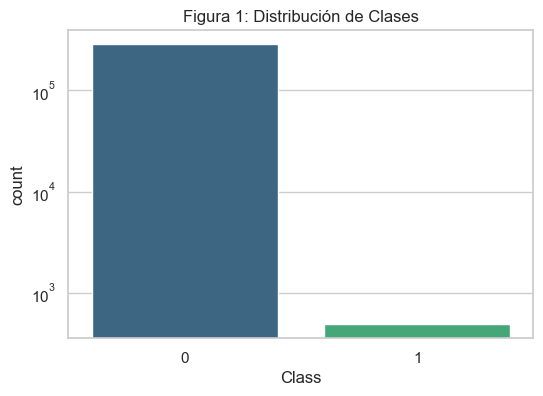

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title("Figura 1: Distribución de Clases")
plt.yscale('log') # Escala logarítmica para visibilizar el fraude
plt.show()

<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>4. Análisis por Niveles de Monto</h2></div>

He decidido agrupar los montos en categorías para ver mejor cómo se distribuyen las compras.

**Mi interpretación:** La mayoría de las compras están en el nivel "Muy Bajo". Esto me da a pensar que los estafadores podrían intentar hacer compras chiquitas para pasar desapercibidos entre toda esa cantidad de transacciones normales.

C:\Users\joser\AppData\Local\Temp\ipykernel_19908\2590038538.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Amount_cat', data=df, palette='magma')


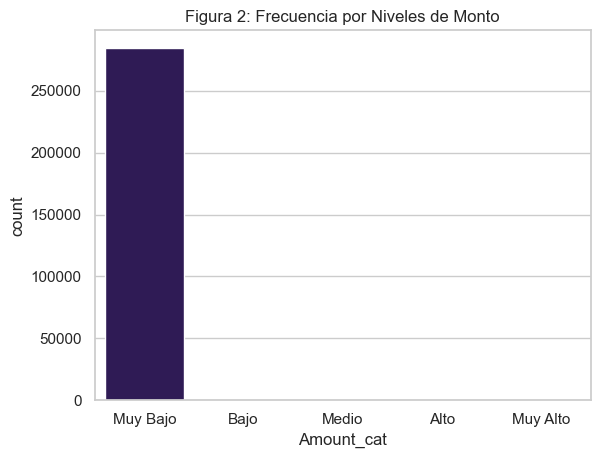

In [10]:
df['Amount_cat'] = pd.cut(df['Amount'], bins=5, labels=['Muy Bajo','Bajo','Medio','Alto','Muy Alto'])
sns.countplot(x='Amount_cat', data=df, palette='magma')
plt.title("Figura 2: Frecuencia por Niveles de Monto")
plt.show()

<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>5. Mapa de Correlación</h2></div>

Aquí vamos a ver qué columnas tienen más que ver con que una transacción sea fraude. Uso una máscara para no repetir los datos en el triángulo de arriba.

**Mi interpretación:** Como las variables V1-V28 vienen de un PCA, no se estorban entre ellas. Pero si miramos bien, variables como V17 y V14 tienen colores más fuertes respecto a la clase. Esas van a ser las variables clave para que mi modelo aprenda a distinguir un fraude.

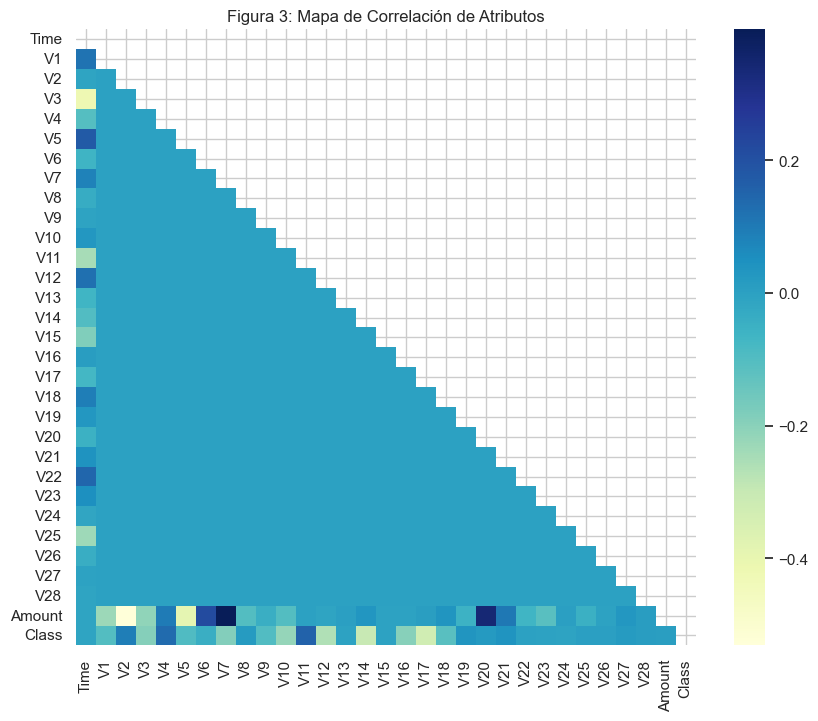

In [11]:
cr = df.drop(['Amount_cat'], axis=1).corr()
mask = np.triu(np.ones_like(cr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(cr, mask=mask, cmap="YlGnBu")
plt.title("Figura 3: Mapa de Correlación de Atributos")
plt.show()

<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>6. Análisis de Outliers (Valores atípicos)</h2></div>

Voy a graficar los datos en 3D para ver dónde andan los fraudes en comparación con las compras normales.

**Mi interpretación:** En la gráfica se ve claro que los fraudes (los rojos) están como "regados" por fuera del grupo principal. En otros trabajos nos dicen que borremos los outliers, pero aquí **no los voy a borrar**. Si los quito, estaría borrando justamente los fraudes, que es lo que quiero encontrar.

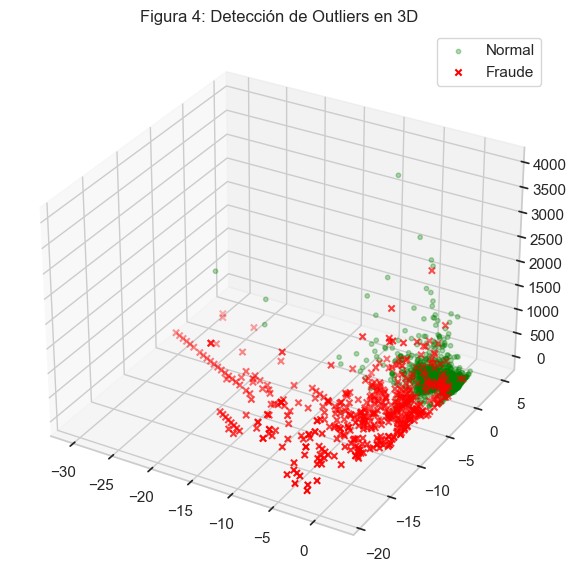

In [12]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
normales = df[df['Class'] == 0].sample(2000, random_state=42)
fraudes = df[df['Class'] == 1]
ax.scatter(normales['V1'], normales['V14'], normales['Amount'], c='green', s=10, alpha=0.3, label='Normal')
ax.scatter(fraudes['V1'], fraudes['V14'], fraudes['Amount'], c='red', s=20, marker='x', label='Fraude')
ax.set_title("Figura 4: Detección de Outliers en 3D")
plt.legend()
plt.show()

<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>7. Relación entre Monto y Tiempo</h2></div>

En esta parte del análisis, el objetivo es cruzar las dos variables que no pasaron por la transformación PCA: Time y Amount. Lo que busco es identificar si existe algún patrón temporal en los ataques o si el fraude se concentra en rangos de dinero específicos.

Al graficar la dispersión (scatter plot), podemos observar cómo se comportan las transacciones normales frente a los fraudes a lo largo de las 48 horas de registro. Técnicamente, esto nos sirve para validar si el fraude es un evento aleatorio en el tiempo o si ocurre en "ráfagas". También es clave para notar que muchos fraudes mantienen montos bajos para no levantar sospechas en los sistemas de monitoreo automáticos, algo que visualmente confirmaremos con los puntos rojos en la gráfica.

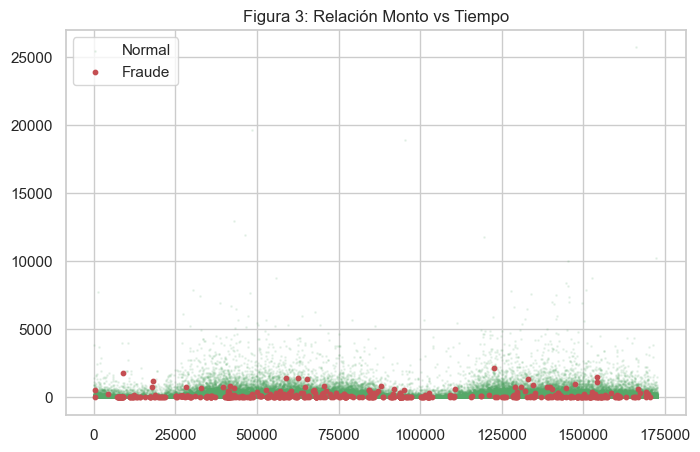

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df[df.Class == 0]['Time'], df[df.Class == 0]['Amount'], c='g', s=1, label='Normal', alpha=0.1)
plt.scatter(df[df.Class == 1]['Time'], df[df.Class == 1]['Amount'], c='r', s=10, label='Fraude')
plt.title("Figura 3: Relación Monto vs Tiempo")
plt.legend()
plt.show()

<div style="color:#3c4d5a; border-top: 7px solid #42A5F5; border-bottom: 7px solid #42A5F5; padding: 10px; text-align: center;"><h2>Interpretación Final de los Resultados</h2></div>

El análisis exploratorio realizado sobre este conjunto de datos permite concluir que nos enfrentamos a un escenario de detección de anomalías sumamente complejo, donde la integridad de la información es alta gracias a la ausencia total de valores nulos, pero el reto técnico reside en el desbalance extremo de las transacciones. Al observar que el fraude constituye apenas una fracción mínima del volumen total, queda claro que cualquier modelo predictivo que se desarrolle debe priorizar la detección de la clase minoritaria mediante métricas como el Recall y el AUPRC, dejando de lado la precisión global que resultaría engañosa en este contexto financiero.

Un hallazgo fundamental de este estudio es la naturaleza de los valores atípicos, los cuales, lejos de ser errores de medición que deban eliminarse, representan la firma característica de la actividad delictiva. El análisis tridimensional y la dispersión de los datos confirman que el fraude se manifiesta como una desviación estadística significativa respecto al comportamiento habitual, lo que exige conservar estos "outliers" para que el modelo pueda aprender a reconocerlos. Finalmente, gracias al análisis de correlación, se han identificado variables críticas como V17 y V14 que actúan como indicadores clave, sugiriendo que el éxito del modelado posterior dependerá de una estrategia que compense el desequilibrio de datos, ya sea mediante pesos de clase balanceados o técnicas de remuestreo, asegurando así una vigilancia robusta contra las transacciones fraudulentas.